<a href="https://colab.research.google.com/github/Redcoder815/Machine_Learning_Project/blob/main/InsurancePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.preprocessing import StandardScaler

In [162]:
insurance_data = pd.read_csv('/content/insurance.csv')

In [163]:
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [164]:
insurance_data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [165]:
insurance_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [166]:
insurance_data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [167]:
insurance_data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


/tmp/ipython-input-2202158030.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_data['age'])


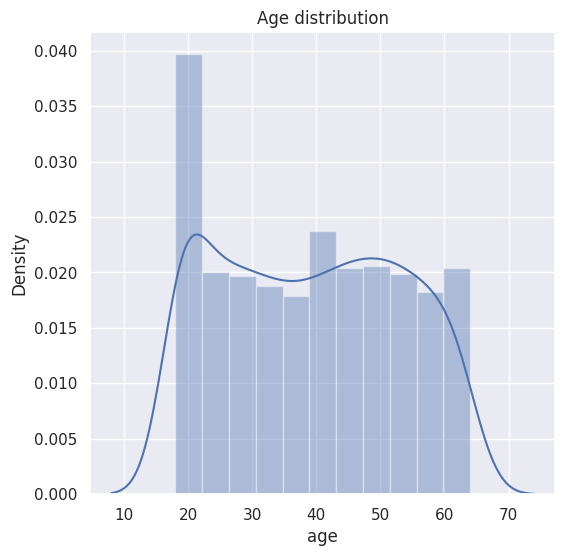

In [168]:
sns.set()
plt.figure(figsize = (6,6))
sns.distplot(insurance_data['age'])
plt.title('Age distribution')
plt.show()

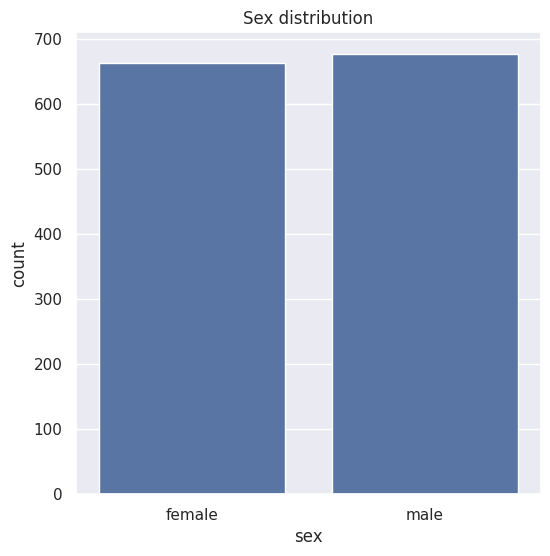

In [169]:
plt.figure(figsize=(6,6))
sns.countplot(x='sex', data = insurance_data)
plt.title('Sex distribution')
plt.show()

In [170]:
insurance_data['sex'].value_counts()

,count
sex,
male,676
female,662


/tmp/ipython-input-2438408727.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_data['bmi'])


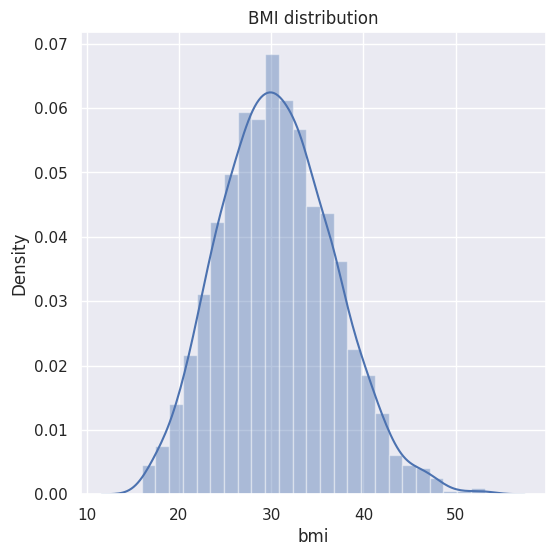

In [171]:
plt.figure(figsize=(6,6))
sns.distplot(insurance_data['bmi'])
plt.title('BMI distribution')
plt.show()

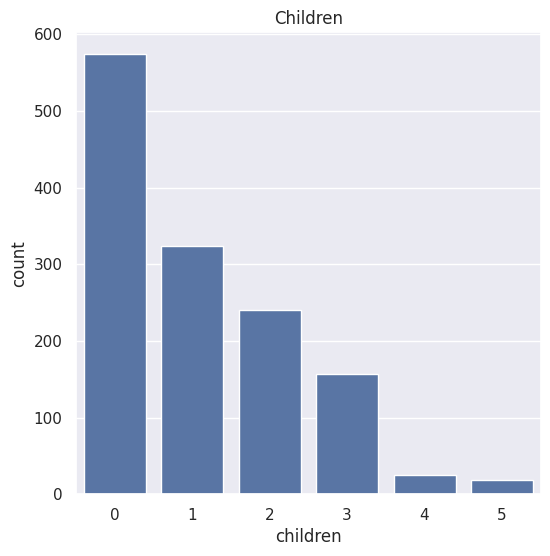

In [172]:
plt.figure(figsize=(6,6))
sns.countplot(x='children', data = insurance_data)
plt.title('Children')
plt.show()

In [173]:
insurance_data['children'].value_counts()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


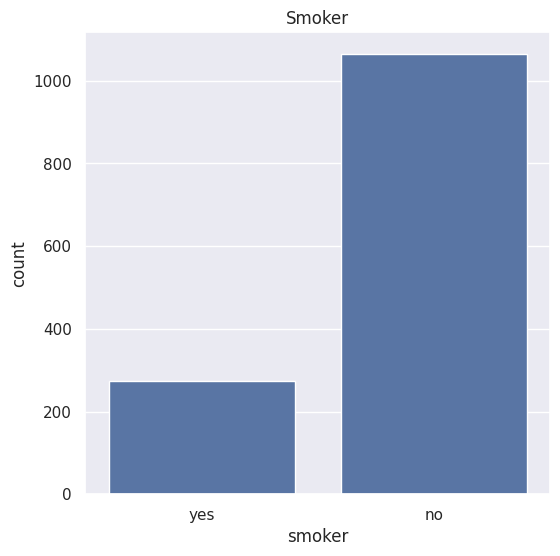

In [174]:
plt.figure(figsize=(6,6))
sns.countplot(x='smoker', data = insurance_data)
plt.title('Smoker')
plt.show()

In [175]:
insurance_data['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


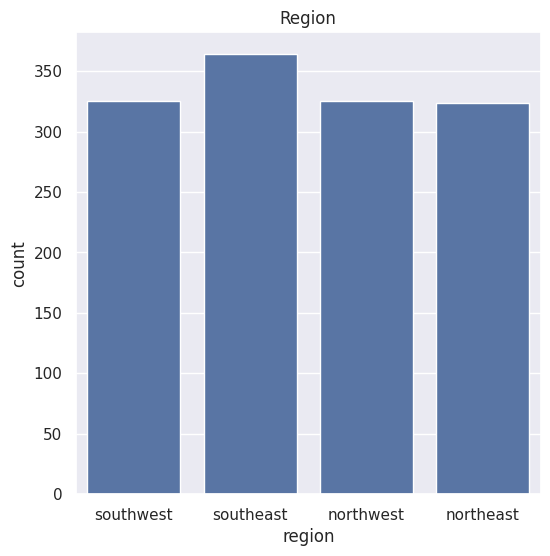

In [176]:
plt.figure(figsize=(6,6))
sns.countplot(x='region', data = insurance_data)
plt.title('Region')
plt.show()

In [177]:
insurance_data['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


/tmp/ipython-input-1166218664.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_data['charges'])


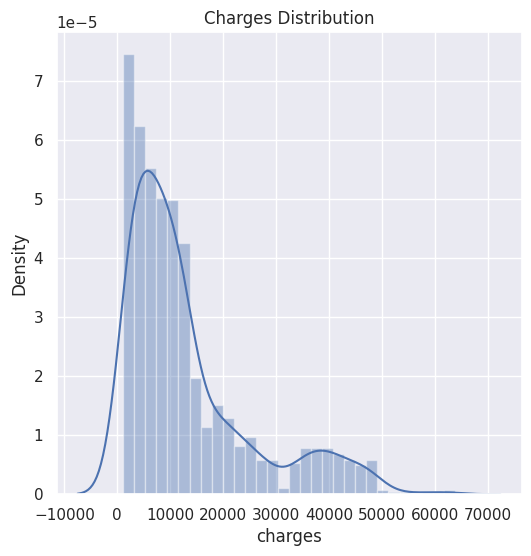

In [178]:
plt.figure(figsize=(6,6))
sns.distplot(insurance_data['charges'])
plt.title('Charges Distribution')
plt.show()

In [179]:
insurance_data.replace({'sex':{'male':0, 'female':1}}, inplace=True)
insurance_data.replace({'smoker':{'no':0, 'yes':1}}, inplace = True)
insurance_data.replace({'region':{'southeast':0,'southwest':1,'northeast':2,'northwest':3}}, inplace=True)

/tmp/ipython-input-272443441.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_data.replace({'sex':{'male':0, 'female':1}}, inplace=True)
/tmp/ipython-input-272443441.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_data.replace({'smoker':{'no':0, 'yes':1}}, inplace = True)
/tmp/ipython-input-272443441.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the 

In [180]:
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,1,16884.92400
1,18,0,33.770,1,0,0,1725.55230
2,28,0,33.000,3,0,0,4449.46200
3,33,0,22.705,0,0,3,21984.47061
4,32,0,28.880,0,0,3,3866.85520


In [181]:
X = insurance_data.drop(columns = 'charges', axis = 1)
Y = insurance_data['charges']

In [182]:
print(X)

      age  sex     bmi  children  smoker  region
0      19    1  27.900         0       1       1
1      18    0  33.770         1       0       0
2      28    0  33.000         3       0       0
3      33    0  22.705         0       0       3
4      32    0  28.880         0       0       3
...   ...  ...     ...       ...     ...     ...
1333   50    0  30.970         3       0       3
1334   18    1  31.920         0       0       2
1335   18    1  36.850         0       0       0
1336   21    1  25.800         0       0       1
1337   61    1  29.070         0       1       3

[1338 rows x 6 columns]


In [183]:
print(Y)

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


In [184]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [185]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [186]:
print(X.shape, X_train.shape, X_test.shape)

(1338, 6) (1070, 6) (268, 6)


In [187]:
import numpy as np

class LinearRegression:
  def __init__(self, lr = 0.01, iterations = 1000):
    self.lr = lr
    self.iterations = iterations
    self.m = None # Coefficients (vector)
    self.b = 0    # Intercept (scalar)

  def fit(self, X, y):
    # Convert X and y to numpy arrays for consistent matrix operations
    X_np = X.values if isinstance(X, pd.DataFrame) else X
    y_np = y.values if isinstance(y, pd.Series) else y

    n_samples, n_features = X_np.shape

    # Initialize coefficients (m) and intercept (b)
    self.m = np.zeros(n_features)
    self.b = 0

    # Gradient Descent
    for _ in range(self.iterations):
      # Calculate predictions
      y_pred = X_np.dot(self.m) + self.b

      # Calculate gradients
      errors = y_np - y_pred
      dm = (-2 / n_samples) * X_np.T.dot(errors)
      db = (-2 / n_samples) * np.sum(errors)

      # Update parameters
      self.m = self.m - (self.lr * dm)
      self.b = self.b - (self.lr * db)

  def predictions(self, X):
    # Convert X to numpy array for prediction
    X_np = X.values if isinstance(X, pd.DataFrame) else X
    return X_np.dot(self.m) + self.b

In [188]:
model = LinearRegression()

In [189]:
model.fit(X_train, Y_train)

In [190]:
def r2_score_scratch(y_true, y_pred):
    # 1. Calculate the mean of the actual values
    y_mean = np.mean(y_true)

    # 2. Calculate Sum of Squares Residual (SS_res)
    # This measures the error of the model
    ss_res = np.sum((y_true - y_pred)**2)

    # 3. Calculate Total Sum of Squares (SS_tot)
    # This measures the natural variation in the data
    ss_tot = np.sum((y_true - y_mean)**2)

    # 4. Calculate R2
    r2 = 1 - (ss_res / ss_tot)

    return r2


In [191]:
training_data_prediction = model.predictions(X_train)

In [192]:
r2_train = r2_score_scratch(Y_train, training_data_prediction)
print(r2_train)

0.7413131194887524


In [193]:
test_data_prediction = model.predictions(X_test)

In [194]:
r2_test = r2_score_scratch(Y_test, test_data_prediction)
print(r2_test)

0.7830215841496619


In [201]:
# input_data = (31,1,25.74,0,1,0)
# input_data = (19,1,27.90,0,1,1)
input_data = (18,0,33.77,1,0,0)
input_data_as_array = np.asarray(input_data)
input_data_reshaped = input_data_as_array.reshape(1,-1)
input_data_scaled = scaler.transform(input_data_reshaped)
prediction = model.predictions(input_data_scaled)

print(prediction)
print('The isurance cost is ', prediction[0])

[3777.17223497]
The isurance cost is  3777.1722349665724


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
